<a href="https://colab.research.google.com/github/Alokathilakarathna/ME422_B3/blob/main/RIgid%20Body%20Control/e20452.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center" style="font-family: 'Times New Roman';"><b>RIGID BODYC ONTROL SYSTEMS LABORATORY</b></p>
<p align="center" style="font-family: 'Times New Roman'; color: #555;">ME 422: Mechanical Systems Lab</p>
<hr/>
<p align="center"> W.S.P.Y.J.C.YAPA   |  E/20/452</p>
<hr/>

# **Activity 1 - Twin rotor system dynamic model**

## Definition of Coordinate Frames and Rotational Matrices

<p align="center">
  <img src="https://raw.githubusercontent.com/Alokathilakarathna/ME422_B3/main/images/TR_frames.png" />
  <br>
  <i>Figure 01: Setup and Coordinate Frame Definition</i>
</p>

Considering the physical structure of the setup, let's define three coordinate frames,
1. Inertial Frame $(e)$: The fixed global frame.
2. Intermediate Frame $(c)$: Fixed to the vertical pillar. It rotates relative to e around the vertical axis $(e_3  \equiv c_3)$ by the yaw angle $θ$.
3. Body Frame $(b)$: Fixed to the pitching arm. It rotates relative to c around the horizontal axis $(c_1  \equiv b$1)$ by the pitch angle $ϕ$

as shown in figure 01.

The relation between those frames are,

$$ c = e R_3(θ)$$
$$ b = c R_1(ϕ)$$

Therefore,

$$ b = e R_3(θ) R_1(ϕ)$$
$$ b = e R \tag{01}$$

Where, $R$ is the Rotational matrix.

Since,
$$
R_1(\phi)=\begin{bmatrix}
1&0&0\\
0&\cos{\phi}&-\sin{\phi}\\
0&\sin{\phi}&\cos{\phi}
\end{bmatrix}
$$

and

$$
R_3(\theta)=\begin{bmatrix}
\cos{\theta}&-\sin{\theta}&0\\
\sin{\theta}&\cos{\theta}&0\\
0&0&1
\end{bmatrix}
$$

Final Rotational Matrix,
$$R = R_3 R_1 = \begin{bmatrix}
\cos{\theta}&-\cos{\phi}\sin{\theta}&\sin{\phi}\sin{\theta}\\
\sin{\theta}&\cos{\phi}\cos{\theta}&-\sin{\phi}\cos{\theta}\\
0&\sin{\phi}&\cos{\phi}\end{bmatrix} \tag{02}$$



## Derivation of Kinematic Equation




From (02),

$$ R = R_3 R_1 $$
By taking time derivative,
$$ \dot{R} = \dot{R_3} R_1 +  R_3 \dot{R_1} \tag{03}$$

For any rotation matrix,
$$ \dot{R} = \hat{ω} R = R \hat{Ω}$$
Where $ω$ is spatial angular velocity and $Ω$ is body angular velocity.

Therefore,
$$ \dot{R_1} = \hat{ω_1} R_1 $$
$$ \dot{R_3} = \hat{ω_2} R_3 $$

By substituing that back to 03,

$$\dot{R} = \hat{\omega}_3 (R_3 R_1) + R_3 \hat{\omega}_1(R_3^T R_3)R_1 $$
$$\dot{R} = \hat{\omega}_3 R + (R_3 \hat{\omega}_1 R_3^T)R$$

$$\dot{R} = (\hat{\omega}_3  + (R_3 \hat{\omega}_1 R_3^T))R$$

$$\dot{R} = \hat{ω} R  \tag{04}$$

Where,
$$\hat{ω} = \hat{\omega}_3  + (R_3 \hat{\omega}_1 R_3^T)$$

By simplifying this,

$$ \hat{\omega} = \begin{bmatrix}
0&-\dot{\theta}&\dot{\phi}\sin{\theta}\\
\dot{\theta}&0&-\dot{\phi}\cos{\theta}\\
-\dot{\phi}\sin{\theta}&\dot{\phi}\cos{\theta}&0
\end{bmatrix}\tag{05}$$


Therefore we can rewrite $Ω$ and $ω$ using $θ$ and $ϕ$ as follow,

$\omega = \begin{bmatrix}
\dot{\phi} \cos{\theta} \\
\dot{\phi} \sin{\theta} \\
\dot{\theta}
\end{bmatrix}$

$
\Omega = R^T \omega = \begin{bmatrix}
\dot{\phi} \\
\dot{\theta} \sin{\phi} \\
\dot{\theta} \cos{\phi}
\end{bmatrix}
$

## Derivation of Torque Equation

In a body frame the angular momentum ($p$),
$$p = 𝕀Ω$$

Then the spatial angular momentum ($π$),

$$π = R p = R 𝕀 Ω$$
$$π = R 𝕀 R_T ω$$
$$π = 𝕀^R ω$$

In here $𝕀^R$ is defined as spatial inertia tensor.

Then by inverting inertial matrix we get the given equation,

$$ω = (𝕀^R)^{-1} π$$

By fundamental law of rotational dynamics,
$$ \dot{π} = \sum τ_{ext}$$

In this setup the external moment has been split into two distinct parts,

1. The manipulatable control moment - $\tau^u$
1. The unmanipulatable constraint moment - $\tau^e$ (Which occurs due to the pivot preventing rotation about the $b_2$ axis)

Therefore,
$$ \dot{π} = \tau^u + \tau^e \tag{06}$$


## Defining $\tau^u$ and $\tau^e$

*In here the derivation are done for general setup (for any rotor orientation)*

Let's define following terms for trust generatedby the two rotors,

- $u_1$ : The raw control input (thrust force) generated by the first rotor.

- $u_2$: The raw control input (thrust force) generated by the second rotor.

- $α$: The physical tilt angle of the first rotor. (It defines the angle between Rotor 1's thrust direction and the vertical pitch axis $b_1$)

- $β$: The physical tilt angle of the second rotor. (It defines the angle between Rotor 2's thrust direction and the vertical pitch axis $b_1$)


Considering this terms,

$$
T^u = \begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}
$$

\begin{align*}
\tau_u &=RT^u=R\begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}
\end{align*}

This can rewrite as,
$$
\tau_u =R\begin{bmatrix}
1 & 0\\
0 & 0\\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos{\alpha} & -\cos{\beta}\\
\sin{\alpha} & -\sin{\beta}
\end{bmatrix}
\begin{bmatrix}
u_1\\ u_2
\end{bmatrix} \tag{07}$$

The constriant moment acting on the system prevents a rotation about $b_2$ axis therere,

From Euler's rigid body equations,

$$
T^e = \Omega \times \mathbb{I}\Omega+\mathbb{I}\dot{\Omega}
$$

To isolate $T_2$ multiply it by $e_2$ and we can take following equation,

$$
T_2 = e_2^T (\Omega \times \mathbb{I}\Omega+\mathbb{I}\dot{\Omega})
$$


Therefore,

$$
T^e=\begin{bmatrix}0\\T_2\\0
\end{bmatrix}
$$

$$
\tau^e=R\begin{bmatrix}0\\T_2\\0
\end{bmatrix}
$$

# **Activity 2 - Simulate and animate the motion of the system for various different realistic inputs**

# **Activity 3 - Desing PID controller for the tracking problem**

## Error Dynamics

The target of the controller is to track a reference target.
Let's Define,
 - $R_r(t)$ : Desired trajectory
 - $ω_r(t)$ : Desired spatial angular velcity
 - $π_r(t)$ : Desired angular momentum


 To then we can define the trajectory error in 3D space using $R$ and $R_r$ which, $R,R_r \mathbb{R}^3\times SO(3)$
$$R_e = R_r R^T \tag{08} $$

From kinetic energy equations, spatial angular velcity error defined by,

$$ \hat{ω_e} ≜ \dot{R_e} R_e^T \tag{09}$$

Therfoer we can prove
$$ \hat{ω_e} = \hat{ω_r}(t) - R_e \hat{ω}(t) R_e^T$$
and
$$ω_e = ω_r- R_e ω \tag{10}$$



From kinetic energy equations, spatial angular momentum error defined by,
$$ \pi_e\triangleq R𝕀R_r^T\omega_e $$

from 10,
$$ \pi_e = R𝕀R_r^T(ω_r- R_e ω) $$
$$ \pi_e = R_e^T\pi_r-\pi \tag{11}$$

By differentiating (11),
$$ \dot{\pi}_e = R_e^T(\dot{\pi}_r-\omega_e\times \pi_r)-\dot{\pi} \tag{12}$$

Take,
$$ \pi_r = R_r \Pi_r$$
Where, $\Pi$ is body angular momentum and $\Pi_r$ is desired body angular momentum.

Then,
$$ \dot{\pi_r} = \dot{R_r} \Pi_r + R_r\dot{\Pi_r}$$

By substituting that to (12),
$$ \dot{\pi}_e =  R_e^T(R_r\dot{\Pi}_r+(\omega_r-\omega_e)\times \pi_r)-\dot{\pi}$$

$$ \dot{\pi}_e = (R\dot{\Pi}_r+\omega\times \pi_r)-\dot{\pi}\tag{13}$$


Therefore from (09), (13) and (06) we get our final error dynamics,
$$
\dot{R}_e =\widehat{\omega}_eR_e \tag{14}
$$
$$
\dot{\pi}_e =(R\dot{\Pi}_r+\omega\times \pi_r)-\tau_u-\tau_e\tag{15}
$$

## Derivation of PID Controller

Take Proportional Configuration Error Vector as $e_R$, it is a mathematical representation of how far setup's current orientation is twisted away from the target's orientation.

Then in intergral of that error is defined as,
$$\dot{e}_{I_R} = e_R$$

Let's take that the error dynamics $(π_e)$ is equal to the standard PID formula,
$$\dot{\pi}_e=-k_{P_R}e_R-k_{D_R}\pi_e-k_{I_R}e_{I_R} \tag{16}$$

 - $-k_{P_R}e_R$ : The Proportional spring (pulls the angle to the target).
 - $-k_{D_R}\pi_e$ : The Derivative damper (slows down the spin to prevent overshooting).
 - $-k_{I_R}e_{I_R}$ : The Integral memory (Make system robust for steady physical forces like gravity)

From (15) and (16),

$$ -k_{P_R}e_R-k_{D_R}\pi_e-k_{I_R}e_{I_R} = (R\dot{\Pi}_r+\omega\times \pi_r)-\tau_u-\tau_e$$

therefore,
$$\tau_u =-
\tau_e+(R\dot{\Pi}_r+\omega\times \pi_r)+k_{P_R}e_R+k_{D_R}\pi_e+k_{I_R}e_{I_R}\tag{17}$$

This is out Control Law.


Our objective is to minimize the error, in this case we need to pull $R_e$ to $I$, Identity matrix. For that we introduce a Lyapunov function which is the Virtual Potential Energy Function, $V(R_e)$.

$$V(R_e) = \frac{1}{2}trace(K(I-R_e))\tag{18}$$

Where, $K = diag\{\mathbb{K}_1,\mathbb{K}_2,\mathbb{K}_3\}$, and $\mathbb{K}_1,\mathbb{K}_2,\mathbb{K}_3$ are distinct constants.

Then the virtual spring forces are given by, spacial gradient of that energy. Therefore,

$$ \hat{e}_R = \frac{1}{2} (R_eK - (R_e K)^T)$$

since K is a diagonal matrix, Therefore $K = K^T$,

$$ \hat{e}_R = \frac{1}{2} (R_eK - KR_e^T )\tag{19}$$


## Control Summary



Proportional configuration error,
$$ \hat{e}_R = \frac{1}{2} (R_eK - KR_e^T )$$

Control Law,
$$\tau_u =-
\tau_e+(R\dot{\Pi}_r+\omega\times \pi_r)+k_{P_R}e_R+k_{D_R}\pi_e+k_{I_R}e_{I_R}$$


To implement this, we need to find, $R_e, K, \tau_e, R, \dot{\Pi_r},\omega, \pi_r,\pi_e, e_R$

### 01. The Current State
R: The current (3x3) rotation matrix of twin rotor
$$R = \begin{bmatrix}
\cos{\theta}&-\cos{\phi}\sin{\theta}&\sin{\phi}\sin{\theta}\\
\sin{\theta}&\cos{\phi}\cos{\theta}&-\sin{\phi}\cos{\theta}\\
0&\sin{\phi}&\cos{\phi}\end{bmatrix}$$
ω: The current (3x1) spatial angular velocity vector
$$\omega = \begin{bmatrix}
\dot{\phi} \cos{\theta} \\
\dot{\phi} \sin{\theta} \\
\dot{\theta}
\end{bmatrix}$$
π: The current spatial angular momentum
$$
\Omega= \begin{bmatrix}
\dot{\phi} \\
\dot{\theta} \sin{\phi} \\
\dot{\theta} \cos{\phi}
\end{bmatrix}
$$

Then,
$$\pi = R 𝕀 Ω$$

### 02. Tuning Parameters

K: The proportional gain matrix
$$K = diag\{\mathbb{K}_1,\mathbb{K}_2,\mathbb{K}_3\}$$

$k_{P_R},k_{D_R},k_{I_R}$: The standard PID scalar gains.

### 03. The Target Trajector

$R_r$: The target rotation matrix

Let $\theta_r(t)$ be the desired yaw angle and $\phi_r(t)$ be the desired pitch angle.

$$R_r = \begin{bmatrix}
\cos\theta_r & -\sin\theta_r \cos\phi_r & \sin\theta_r \sin\phi_r \\
\sin\theta_r & \cos\theta_r \cos\phi_r & -\cos\theta_r \sin\phi_r \\
0 & \sin\phi_r & \cos\phi_r
\end{bmatrix}$$

$Ω_r$: The target body angular velocity

body angular velocity of the target is just the pitch rate ($\dot{ϕ}_r$) and the yaw rate ($\dot{θ}_r$)

$$\Omega_r = \begin{bmatrix}
\dot{\phi}_r \\
\dot{\theta}_r \sin\phi_r \\
\dot{\theta}_r \cos\phi_r
\end{bmatrix}$$

$\dot{Ω}_r$: The target body angular acceleration

$π_r$: Calculate the target's spatial momentum


$$π_r = R_r 𝕀 \Omega_r$$
$\dot{Π}_r$: Calculate the target's internal momentum acceleration
$$\dot{\Pi}_r = 𝕀 \dot{\Omega}_r$$

### 04. Error Calculations

$R_e$: The trajectory error matrix
$$R_e = R_r R^T$$

$\pi_e$: The momentum error
$$\pi_e = R_e^T \pi_r - \pi$$

$\hat{e}_R$: The proportional error matrix
$$ \hat{e}_R = \frac{1}{2} (R_eK - KR_e^T )$$


### 05. The Physical Constraint

$τ_e$: The physical joint restriction
$$
\tau^e=R\begin{bmatrix}0\\e_2^T (\Omega \times \mathbb{I}\Omega+\mathbb{I}\dot{\Omega})\\0
\end{bmatrix}
$$


## Calcualating Inertia Matrix

Let's define setup in simplified shapes.
- The Arm: A slender solid cylinder with mass $m_a$ radius $r_a$, and a total length of $2L_a$ (The distance from the center pivot to one end is $L_a$).

- The Rotors: Two solid discs (motors + propellers) with mass $m_r$ and radius $r_r$, distance from center pivot to motor is $L_r$.

$I_1$: Pitch Inertia (Around the $b_1$ axis)

$$I_1 = \frac{1}{3}m_a L_a^2 + 2 m_r L_r^2$$

$I_2$: Roll Inertia (Around the $b_2$ axis)

$$I_2 = \frac{1}{2}m_a r_a^2 +  m_r r_r^2$$

$I_3$: Yaw Inertia (Around the $b_3$ axis)

$$I_3 = I_1 = \frac{1}{3}m_a L_a^2 + 2 m_r L_r^2$$


Final matrix,

$$ 𝕀 = diag\{ I_1, I_2, I_3 \}$$

# **Activity 4 - Experimentally verify the stability properties of the controller**

# **Extra - Trust Vectoring**

Reccall from eq. (7),
$$
T_u=\begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}
$$

In this setuo we have 4 controllable parameters. But we only need 2DOF. Therefore there are differnt methord to reduce this two. In the lab setup we have, fixed $\alpha$ and $\beta$ and we conrol $u_1$ and $u_2$. But in this sometimes two rotors produce forces that cancel each other out wasting energy.

Another methors is trust vectoring apparach. we can maps desired torque to specific rotor angles and thrusts.

For that let's set,
$$\beta=\alpha$$
Then we have
$$
R^T\tau_u=T_u=\begin{bmatrix}
(u_1-u_2)\cos{\alpha}\\
0\\
(u_1-u_2)\sin{\alpha}
\end{bmatrix}
$$

Let's take,
Differential thrust which used to tilt and move,
$$u_{-}=(u_1-u_2)$$
Total thrust which maintain altitude (if flying),
$$ u_{+}=(u_1+u_2)$$


Then we can get,
$$
u_{-} =\sqrt{e_1^TR^T\tau_u} = \sqrt{ T_{u,1}^2 + T_{u,3}^2 }
$$


$$
\alpha = \tan^{-1}(\frac{e_3^TR^T\tau_u}{e_1^TR^T\tau_u}) = \tan^{-1}(\frac{T_{u,3}}{T_{u,1}})
$$

# Extra - Optimum Trust Angles for Fixed Setup

In twin rotor setup if our object is not to fly, only to maintain the orientation, and we can't control the angles $\alpha$ and $\beta$ we should be able to find a optimum angles to fixed them to overcome inertia in the most effectve way.

If we compute this based on inertia we should be able to accelerate pitch and yaw at the same rate.

if inertia around $b_1$ is $I_1$ and  $b_2$ is $I_2$ respectively.
To decouple take,
$$ \alpha = - \beta $$

$$
T_u=\begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}
$$

Therfore,

$$T_{u,1} = (u_1 - u_2)cos(α)$$
$$T_{u,3} = (u_1 + u_2)sin(α)$$

Now total trust control yaw and differential trust control pitch.
And,

$$


In [1]:


#@title Colab setup and imports

import jax
from jax import numpy as jp
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
import matplotlib.pyplot as plt

try:
  import brax
except (ImportError, ModuleNotFoundError):
  from IPython.display import clear_output
  !pip install git+https://github.com/google/brax.git@main
  clear_output()
  import brax



Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


In [2]:
import brax
from brax.io import mjcf

trms_xml = """
<mujoco>
  <option timestep="0.01" gravity="0 0 -9.81"/>
  <worldbody>
    <light diffuse=".5 .5 .5" pos="0 0 3"/>
    <body name="base" pos="0 0 0">
      <geom type="cylinder" size="0.05 0.5" rgba="0.5 0.5 0.5 1"/>
      <body name="arm" pos="0 0 0.5">
        <joint name="yaw" type="hinge" axis="0 0 1" range="-180 180"/>
        <joint name="pitch" type="hinge" axis="0 1 0" range="-60 60"/>
        <geom type="capsule" size="0.02 0.3" fromto="-0.3 0 0 0.3 0 0" rgba="0.8 0.1 0.1 1"/>
        </body>
    </body>
  </worldbody>
  <actuator>
    <motor joint="yaw" gear="10"/>
    <motor joint="pitch" gear="10"/>
  </actuator>
</mujoco>
"""

In [3]:
from brax.envs.base import PipelineEnv, State
import jax.numpy as jnp

class TwinRotorEnv(PipelineEnv):
    def __init__(self, **kwargs):
        sys = mjcf.loads(trms_xml)
        super().__init__(sys, backend='mjx', **kwargs) # 'mjx' for MuJoCo XLA backend

    def reset(self, rng):
        # Initialize angles and velocities to zero (plus some noise)
        pipeline_state = self.pipeline_init(self.sys.init_q, jnp.zeros(self.sys.qd_size()))
        obs = self._get_obs(pipeline_state)
        return State(pipeline_state, obs, reward=0.0, done=0.0, metrics={})

    def step(self, state, action):
        # action = [voltage_main, voltage_tail] mapped to motor torques
        pipeline_state = self.pipeline_step(state.pipeline_state, action)
        obs = self._get_obs(pipeline_state)

        # Define reward: distance from setpoint (e.g., pitch=0, yaw=0)
        dist = jnp.linalg.norm(obs[:2])
        reward = -dist

        return state.replace(pipeline_state=pipeline_state, obs=obs, reward=reward)

    def _get_obs(self, data):
        # Return [pitch_angle, yaw_angle, pitch_vel, yaw_vel]
        return jnp.concatenate([data.q, data.qd])

In [4]:
import jax
import jax.numpy as jnp

def pid_step(pid_state, current_val, target_val, dt, params):
    """
    params: (Kp, Ki, Kd)
    pid_state: (integral_error, previous_error)
    """
    kp, ki, kd = params
    integral, prev_error = pid_state

    error = target_val - current_val
    integral = integral + error * dt
    derivative = (error - prev_error) / dt

    output = kp * error + ki * integral + kd * derivative

    return (integral, error), output

In [5]:
def simulate_trms(env, params, timesteps=500):
    dt = env.sys.opt.timestep

    def box_step(carry, t):
        state, pid_p_state, pid_y_state = carry

        # 1. Define Trajectory: Target Pitch = 0.5 * sin(t)
        target_pitch = 0.5 * jnp.sin(t * dt * 2.0)
        target_yaw = 0.0

        # 2. Get current state (Pitch is index 0, Yaw is index 1 in obs)
        current_pitch = state.obs[0]
        current_yaw = state.obs[1]

        # 3. Compute PID Outputs
        new_pid_p, u_pitch = pid_step(pid_p_state, current_pitch, target_pitch, dt, params['pitch'])
        new_pid_y, u_yaw = pid_step(pid_y_state, current_yaw, target_yaw, dt, params['yaw'])

        # 4. Step Environment
        action = jnp.array([u_pitch, u_yaw])
        next_state = env.step(state, action)

        return (next_state, new_pid_p, new_pid_y), (next_state.obs[0], target_pitch)

    # Initial states
    rng = jax.random.PRNGKey(0)
    init_state = env.reset(rng)
    init_pid = (0.0, 0.0) # (integral, prev_error)

    t_range = jnp.arange(timesteps)
    _, (angles, targets) = jax.lax.scan(box_step, (init_state, init_pid, init_pid), t_range)

    return angles, targets

/usr/local/lib/python3.12/dist-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


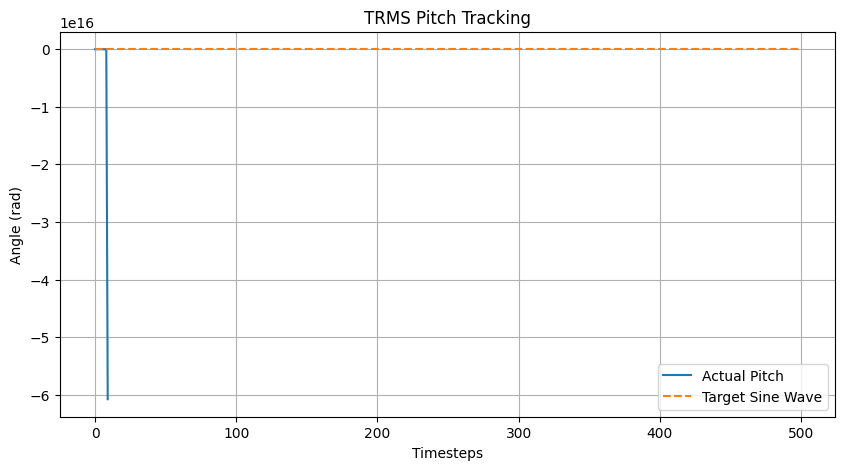

In [6]:
# Tuning Parameters
pid_params = {
    'pitch': (15.0, 5.0, 2.0), # Kp, Ki, Kd
    'yaw': (10.0, 2.0, 1.0)
}

env = TwinRotorEnv()
history, targets = simulate_trms(env, pid_params)

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history, label='Actual Pitch')
plt.plot(targets, '--', label='Target Sine Wave')
plt.legend()
plt.title("TRMS Pitch Tracking")
plt.xlabel("Timesteps")
plt.ylabel("Angle (rad)")
plt.grid(True)
plt.show()

In [7]:
import jax
from brax.io import html

def simulate_with_trajectory(env, params, timesteps=300):
    dt = env.sys.opt.timestep

    def step_fn(carry, t):
        state, p_pid, y_pid = carry

        # Target: Sine wave for pitch
        target_pitch = 0.4 * jnp.sin(t * dt * 3.0)

        # PID Logic (from previous step)
        (new_p_pid, u_p) = pid_step(p_pid, state.obs[0], target_pitch, dt, params['pitch'])
        (new_y_pid, u_y) = pid_step(y_pid, state.obs[1], 0.0, dt, params['yaw'])

        # Step the environment
        next_state = env.step(state, jnp.array([u_p, u_y]))

        # Carry the state forward and return the pipeline_state for rendering
        return (next_state, new_p_pid, new_y_pid), next_state.pipeline_state

    rng = jax.random.PRNGKey(42)
    init_state = env.reset(rng)

    # Run the loop
    _, states_history = jax.lax.scan(
        step_fn,
        (init_state, (0.0, 0.0), (0.0, 0.0)),
        jnp.arange(timesteps)
    )

    return states_history

# Run the simulation
history = simulate_with_trajectory(env, pid_params)

In [ ]:
# This will output an interactive 3D window in your Colab cell
from IPython.display import HTML

# Generate the HTML/JS for the animation
# 'env.sys' contains the geometry definitions from your MJCF
viz_html = html.render(env.sys, history)

# Display it
HTML(viz_html)